<a href="https://colab.research.google.com/github/ivanriuk/Tarea4_Optimizacion2/blob/main/GreedyMDVRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
mutable struct DepotState
    current_truck::Int
    routes::Vector{Vector{Int}} #historial de ruta
    loads::Vector{Float64} #historial de carga
end

struct Candidate
    node::Int
    dist::Float64
end

euclidean2d(a, b) = sqrt((a[1] - b[1])^2 + (a[2] - b[2])^2)

function current_position(state::DepotState, depot_xy, nodes)
    if state.current_truck > length(state.routes) #ya no quedan camiones en el deposito
        return nothing
    end

    route = state.routes[state.current_truck]

    #si no hay ruta se establece la posicion del camion como la del deposito
    if isempty(route)
        return depot_xy
    else
        return @view nodes[route[end], 1:2]     #se establece la posicion del camion como la del ultimo nodo visitado
    end
end

function remaining_capacity(state::DepotState, capacity)
    if state.current_truck > length(state.loads) #ya no quedan camiones en el deposito
        return -1.0 #para detener el proceso
    end
    return capacity - state.loads[state.current_truck]  #se regresa la capacidad restante
end

function advance_truck_if_needed!(state::DepotState, unassigned, nodes, capacity, trucks_per_depot)
    while state.current_truck <= trucks_per_depot
        rem_cap = remaining_capacity(state, capacity) #capacidad restante

        #revisa si existe al menos un cliente posible para el ruteo
        feasible_exists = any(nodes[i, 3] <= rem_cap for i in unassigned)

        if feasible_exists #se continuara con el guardado de ruta
            return true
        else #el camion esta lleno
            #se cambia al sig camion
            state.current_truck += 1
        end
    end

    return false #para regresar al depot
end

#pos = posicion actual ---- cambiar a actual
function nearest_feasible_candidates(pos, unassigned, nodes, rem_cap, k) #cambiar k en base a la cantidad de depots
    candidates = Candidate[]

    for i in unassigned
        demand = nodes[i, 3]
        if demand <= rem_cap #se definen los nodos disponibles donde el camion aun pueda almacenar
            d = euclidean2d(pos, @view(nodes[i, 1:2])) #calculamos la distancia del camion actual a todos los nodos disponibles
            push!(candidates, Candidate(i, d)) #creamos la lista de candidatos posibles
        end
    end

    sort!(candidates, by = c -> c.dist)
    return candidates[1:min(k, length(candidates))] #devuelve los k mejores nodos cercanos; k en base a la cantidad de camiones dsiponibles
end

function select_next_customers(states, depots, nodes, unassigned, capacity, trucks_per_depot)
    ndepots = size(depots, 1)

    choices = Union{Nothing, Int}[nothing for _ in 1:ndepots] #definimos cual nodo querra cada camion
    #union define que solo admite respuesta int o nothing
    candidate_lists = [Candidate[] for _ in 1:ndepots]

    ptr = zeros(Int, ndepots) #indice del candidato actualmente propuesto por el deposito d

    for d in 1:ndepots
        ok = advance_truck_if_needed!(states[d], unassigned, nodes, capacity, trucks_per_depot)
        ok || continue #si ok es false, se activa continue y se salta el for

        pos = current_position(states[d], @view(depots[d, :]), nodes)
        rem_cap = remaining_capacity(states[d], capacity)

        candidate_lists[d] = nearest_feasible_candidates(pos, unassigned, nodes, rem_cap, ndepots)

        if !isempty(candidate_lists[d])
            ptr[d] = 1 #se define al nodo como la mejor opcion para el camion
            choices[d] = candidate_lists[d][1].node
        end
    end

    # -------------------------------------------------
    # Funciones auxiliares
    # -------------------------------------------------

    # nodo actualmente propuesto por el depósito d
    current_node(d) = (
        ptr[d] == 0 || ptr[d] > length(candidate_lists[d]) # es como un "and" para que se cumpla un mejor nodo asignado y que no se pase del tamaño
    ) ? nothing : candidate_lists[d][ptr[d]].node # condicion ? true : false

    # Distancia del candidato actual
    current_dist(d) = (
        ptr[d] == 0 || ptr[d] > length(candidate_lists[d])
    ) ? Inf : candidate_lists[d][ptr[d]].dist # se asigna inf para descartarlo

    # Distancia de la siguiente alternativa
    next_dist(d) = (
        ptr[d] + 1 > length(candidate_lists[d])
    ) ? Inf : candidate_lists[d][ptr[d] + 1].dist

    # -------------------------------------------------
    # Resolver conflictos iterativamente
    # -------------------------------------------------
    while true
        # refrescar choices según los punteros actuales
        for d in 1:ndepots
            choices[d] = current_node(d) #cada camion propone su nodo a moverse
        end

        # agrupar depósitos que están pidiendo el mismo nodo
        groups = Dict{Int, Vector{Int}}() #guarda el (nodo => [lista de camiones])
        for d in 1:ndepots
            node = choices[d]
            node === nothing && continue #resume el if node=nothing => continue
            push!(get!(groups, node, Int[]), d)
            # se obtiene el vector asociado al nodo dentro de groups
            # se crea como vacio en caso de no existir
            # se agrega el deposito asignado al vector recien creado
            # queda groups = Dict(nodo => [camiones])
        end

        any_conflict = false
        any_change = false

        for (node, ds) in groups #resolvemos para nodos conflictuados entre depositos
            if length(ds) > 1 # varios depositos quieren el mismo nodo
                any_conflict = true

                # quien tenga peor alternativa siguiente conserva el nodo compartido
                alt_dists = [next_dist(d) for d in ds]
                max_alt = maximum(alt_dists)

                keepers = [ds[i] for i in eachindex(ds) if alt_dists[i] == max_alt]

                keeper =
                    if length(keepers) == 1
                        keepers[1]
                    else
                        # desempate extra: el más cercano al nodo compartido lo conserva
                        curr_dists = [current_dist(d) for d in keepers]
                        keepers[argmin(curr_dists)]
                    end

                # los demás avanzan a su siguiente candidato
                for d in ds
                    if d != keeper
                        ptr[d] += 1 #cambia a la siguiente mejor opcion
                        any_change = true
                    end
                end
            end
        end

        # terminar cuando ya no haya conflictos
        if !any_conflict || !any_change
            break
        end
    end

    # refrescar choices una última vez
    for d in 1:ndepots
        choices[d] = current_node(d)
    end

    return choices
end

function assign_node!(state::DepotState, node_idx::Int, nodes, capacity) #checar a un nodo especifico si cabe
    if state.current_truck > length(state.routes) #checar si quedan camiones
        return false
    end

    demand = nodes[node_idx, 3]

    if state.loads[state.current_truck] + demand <= capacity
        push!(state.routes[state.current_truck], node_idx) #se actualiza la ruta con el nuevo nodo
        state.loads[state.current_truck] += demand #se actauliza la demanda
        return true
    end

    #si no se encontraron nodos que puedan almacenarse se regresa al depot
    return false
end

function greedy_mdvrp_nn(nodes::AbstractMatrix, depots::AbstractMatrix;
                         trucks_per_depot::Int = 2,
                         capacity::Float64 = 50.0)

    ndepots = size(depots, 1)

    #inicializa definiendo las rutas y pesos en zeros para cada camion
    states = [
        DepotState(
            1,
            [Int[] for _ in 1:trucks_per_depot],
            zeros(Float64, trucks_per_depot)
        )
        for _ in 1:ndepots
    ]

    infeasible = [i for i in 1:size(nodes, 1) if nodes[i, 3] > capacity] #se guradan los nodos que nunca podrian ser visitados
    unassigned = [i for i in 1:size(nodes, 1) if nodes[i, 3] <= capacity] #se guardan todos los nodos factibles pero sin ruta

    while !isempty(unassigned)
        choices = select_next_customers(states, depots, nodes, unassigned, capacity, trucks_per_depot)

        if all(isnothing, choices)
            break
        end

        progress = false

        for d in 1:ndepots
            node = choices[d]
            node === nothing && continue #continue saltaria al sig deposito
            node in unassigned || continue  #checa que no quiera mandar a un nodo infactible

            ok = assign_node!(states[d], node, nodes, capacity) #checar capacidad

            if ok
                filter!(x -> x != node, unassigned) #elimina de las opciones el nodo asignado
                progress = true #flag para indicar que si ocurre algo
            end
        end

        if !progress
            break #ya no hubieron asignaciones disponibles
        end
    end

    return (
        states = states,
        unassigned = unassigned,
        infeasible = infeasible
    )
end

function route_distance(route::Vector{Int}, depot_xy, nodes)
    isempty(route) && return 0.0

    #recordar route es la lista de los indices de los nodo visitados
    #dist depot => nodo 1
    total = euclidean2d(depot_xy, @view(nodes[route[1], 1:2]))

    #dist entre nodos
    for k in 1:length(route)-1
        total += euclidean2d(@view(nodes[route[k], 1:2]), @view(nodes[route[k+1], 1:2]))
    end

    #dist nodo fin => depot
    total += euclidean2d(@view(nodes[route[end], 1:2]), depot_xy)
    return total
end

function print_solution(sol, depots, nodes)
    ndepots = size(depots, 1)
    dist_tot = 0.0

    for d in 1:ndepots
        println("Depot $d")
        for t in 1:length(sol.states[d].routes)
            r = sol.states[d].routes[t]
            load = sol.states[d].loads[t]
            dist = route_distance(r, @view(depots[d, :]), nodes)
            dist_tot += dist

            println("  Truck $t")
            println("    route = $r")
            println("    load  = $load")
            println("    dist  = $(round(dist, digits=3))")
        end
    end
    println("Total distance  = $(round(dist_tot, digits=3))")

    println("\nUnassigned nodes: ", sol.unassigned)
    println("Infeasible nodes: ", sol.infeasible)
end
#feasible_candidates_sorted

print_solution (generic function with 1 method)

In [28]:
depots = [
    20 20
    30 40
    50 30
    60 50
]

# x   y   demand

nodes = [
  5   6   7
  5  25  23
  12  42  21
  17  33  32
  30  48  15
  32  22   9
  37  52   7
  48  28  18
  56  37  10
  63  69   6
]

sol = greedy_mdvrp_nn(nodes, depots; trucks_per_depot=2, capacity=50.0)
print_solution(sol, depots, nodes)

Depot 1
  Truck 1
    route = [6, 2]
    load  = 32.0
    dist  = 55.143
  Truck 2
    route = Int64[]
    load  = 0.0
    dist  = 0.0
Depot 2
  Truck 1
    route = [5, 3, 10]
    load  = 42.0
    dist  = 128.612
  Truck 2
    route = Int64[]
    load  = 0.0
    dist  = 0.0
Depot 3
  Truck 1
    route = [8, 4]
    load  = 50.0
    dist  = 67.365
  Truck 2
    route = [1]
    load  = 7.0
    dist  = 102.0
Depot 4
  Truck 1
    route = [9, 7]
    load  = 17.0
    dist  = 60.896
  Truck 2
    route = Int64[]
    load  = 0.0
    dist  = 0.0
Total distance  = 414.015

Unassigned nodes: Int64[]
Infeasible nodes: Int64[]


In [29]:
using Plots

function plot_solution(sol, depots, nodes; show_labels=true)
    plt = plot(
        title = "MDVRP Greedy Nearest-Neighbor Solution",
        xlabel = "x",
        ylabel = "y",
        legend = :outertopright,
        aspect_ratio = :equal,
        grid = true,
        size = (900, 700)
    )

    # -------------------------
    # Plot all customer nodes
    # -------------------------
    scatter!(
        plt,
        nodes[:, 1], nodes[:, 2],
        label = "Customers",
        markersize = 6
    )

    # Optional node labels
    if show_labels
        for i in 1:size(nodes, 1)
            annotate!(plt, nodes[i, 1] + 0.8, nodes[i, 2] + 0.8, text("N$i", 8))
        end
    end

    # -------------------------
    # Plot depots
    # -------------------------
    scatter!(
        plt,
        depots[:, 1], depots[:, 2],
        label = "Depots",
        markershape = :square,
        markersize = 10
    )

    if show_labels
        for d in 1:size(depots, 1)
            annotate!(plt, depots[d, 1] + 0.8, depots[d, 2] + 0.8, text("D$d", 10))
        end
    end

    # -------------------------
    # Plot routes
    # -------------------------
    route_id = 1

    for d in 1:length(sol.states)
        depot_xy = depots[d, :]

        for t in 1:length(sol.states[d].routes)
            route = sol.states[d].routes[t]

            isempty(route) && continue

            xs = Float64[]
            ys = Float64[]

            # Start at depot
            push!(xs, depot_xy[1])
            push!(ys, depot_xy[2])

            # Visit route nodes
            for node in route
                push!(xs, nodes[node, 1])
                push!(ys, nodes[node, 2])
            end

            # Return to depot
            push!(xs, depot_xy[1])
            push!(ys, depot_xy[2])

            plot!(
                plt,
                xs, ys,
                lw = 2,
                marker = :circle,
                label = "Depot $d - Truck $t"
            )

            route_id += 1
        end
    end

    # -------------------------
    # Highlight unassigned nodes
    # -------------------------
    if hasproperty(sol, :unassigned) && !isempty(sol.unassigned)
        scatter!(
            plt,
            nodes[sol.unassigned, 1],
            nodes[sol.unassigned, 2],
            markersize = 8,
            markershape = :xcross,
            label = "Unassigned"
        )
    end

    return plt
end

plot_solution (generic function with 1 method)

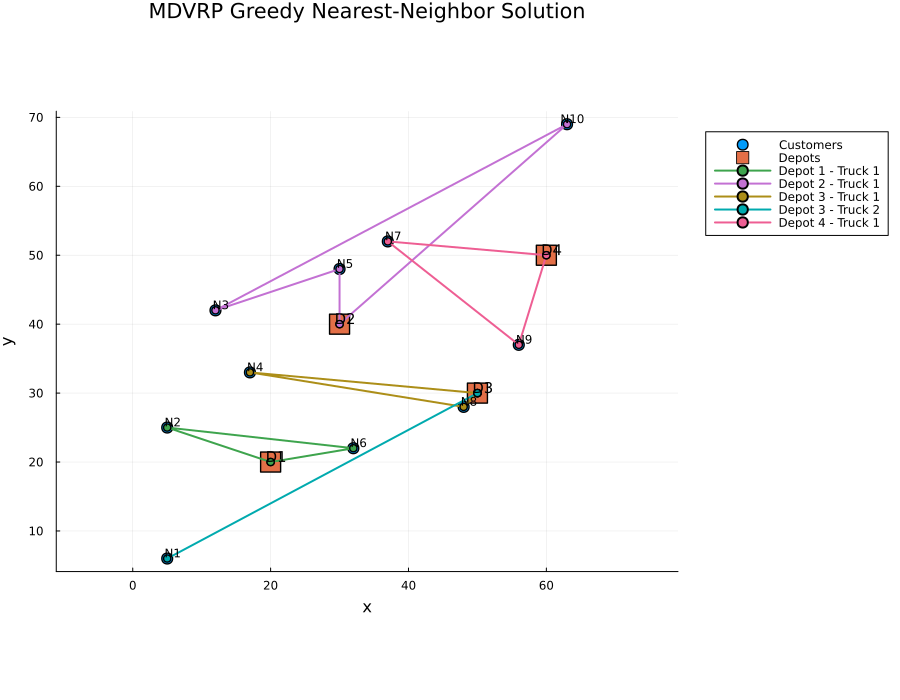

In [30]:
plt = plot_solution(sol, depots, nodes)
display(plt)